In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


### **Download the weather dataset**

In [ ]:
# Download the dataset from Zenodo
!wget -q "https://zenodo.org/records/7525955/files/weather_prediction_dataset.csv?download=1" -O weather_prediction_dataset.csv

# Load the dataset
weather_df = pd.read_csv("weather_prediction_dataset.csv")

print("Dataset Shape:", weather_df.shape)

print("\nFirst 5 rows:")
display(weather_df.head())

print("\nColumn names:")
print(weather_df.columns.tolist())

Dataset Shape: (3654, 165)

First 5 rows:


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5



Column names:
['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max', 'BUDAPEST_cloud_cover', 'BUDAPEST_humidity', 'BUDAPEST_pressure', 'BUDAPEST_global_radiation', 'BUDAPEST_precipitation', 'BUDAPEST_sunshine', 'BUDAPEST_temp_mean', 'BUDAPEST_temp_max', 'DE_BILT_cloud_cover', 'DE_BILT_wind_speed', 'DE_BILT_wind_gust', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max', 'DRESDEN_cloud_cover', 'DRESDEN_wind_speed', 'DRESDEN_wind_gust', 'DRESDEN_humidity', 'DRESDEN_global_radiation', 'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean', 'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover', 'DUSSELDORF_wind_speed', 'DUSSELDORF_wind_gust', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure', 'DUSSELDORF_global_rad

### **Inspect BASEL data**

In [ ]:
# Convert DATE into proper datetime format
weather_df["DATE"] = pd.to_datetime(
    weather_df["DATE"].astype(str),
    format="%Y%m%d"
)

# Select Basel-related columns
basel_cols = [
    "DATE",
    "MONTH",
    "BASEL_cloud_cover",
    "BASEL_humidity",
    "BASEL_pressure",
    "BASEL_global_radiation",
    "BASEL_precipitation",
    "BASEL_sunshine",
    "BASEL_temp_mean",
    "BASEL_temp_min",
    "BASEL_temp_max"
]

basel_df = weather_df[basel_cols].copy()

print("Date range:")
print(basel_df["DATE"].min(), "to", basel_df["DATE"].max())

print("\nDataset shape:", basel_df.shape)

print("\nMissing values:")
print(basel_df.isnull().sum())

print("\nBasel data:")
display(basel_df.head())

Date range:
2000-01-01 00:00:00 to 2010-01-01 00:00:00

Dataset shape: (3654, 11)

Missing values:
DATE                      0
MONTH                     0
BASEL_cloud_cover         0
BASEL_humidity            0
BASEL_pressure            0
BASEL_global_radiation    0
BASEL_precipitation       0
BASEL_sunshine            0
BASEL_temp_mean           0
BASEL_temp_min            0
BASEL_temp_max            0
dtype: int64

Basel data:


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max
0,2000-01-01,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9
1,2000-01-02,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8
2,2000-01-03,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8
3,2000-01-04,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5
4,2000-01-05,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6


### **Plot Basel mean temperature**

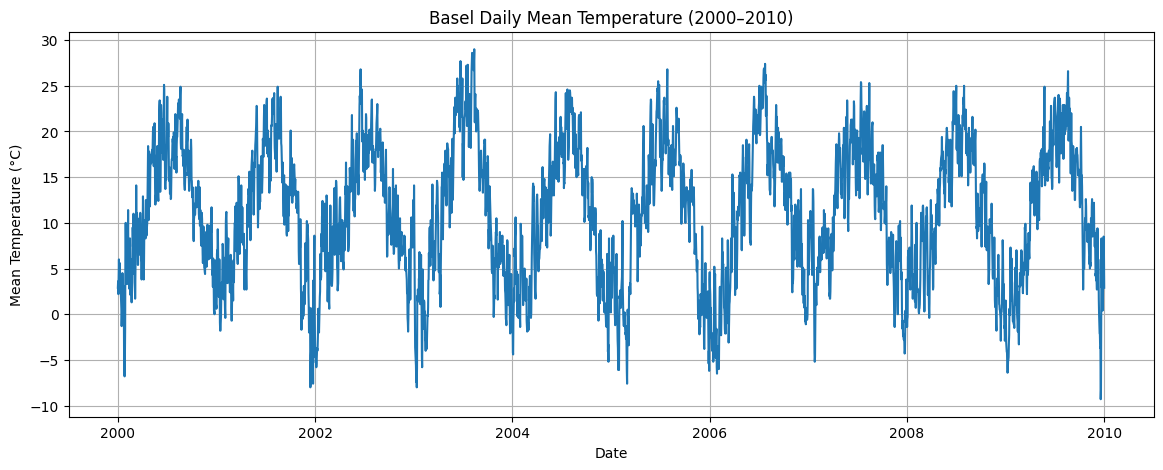

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    basel_df["DATE"],
    basel_df["BASEL_temp_mean"]
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Basel Daily Mean Temperature (2000–2010)")
plt.grid(True)
plt.show()

### **Create features and chronological train/validation/test split**

In [ ]:
# Features used for prediction
base_features = [
    "BASEL_cloud_cover",
    "BASEL_humidity",
    "BASEL_pressure",
    "BASEL_global_radiation",
    "BASEL_precipitation",
    "BASEL_sunshine",
    "BASEL_temp_mean",
    "BASEL_temp_min",
    "BASEL_temp_max"
]

# Create seasonality features
basel_df["month_sin"] = np.sin(2 * np.pi * basel_df["MONTH"] / 12)
basel_df["month_cos"] = np.cos(2 * np.pi * basel_df["MONTH"] / 12)

seasonal_features = base_features + ["month_sin", "month_cos"]

# Target
target = "BASEL_temp_mean"

# Chronological split: 70% train, 15% validation, 15% test
n = len(basel_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

print("Total samples:", n)
print("Training samples:", train_end)
print("Validation samples:", val_end - train_end)
print("Test samples:", n - val_end)

print("\nTrain period:")
print(basel_df["DATE"].iloc[0], "to", basel_df["DATE"].iloc[train_end - 1])

print("\nValidation period:")
print(basel_df["DATE"].iloc[train_end], "to", basel_df["DATE"].iloc[val_end - 1])

print("\nTest period:")
print(basel_df["DATE"].iloc[val_end], "to", basel_df["DATE"].iloc[-1])

print("\nFeatures without seasonality:", len(base_features))
print("Features with seasonality:", len(seasonal_features))

Total samples: 3654
Training samples: 2557
Validation samples: 548
Test samples: 549

Train period:
2000-01-01 00:00:00 to 2006-12-31 00:00:00

Validation period:
2007-01-01 00:00:00 to 2008-07-01 00:00:00

Test period:
2008-07-02 00:00:00 to 2010-01-01 00:00:00

Features without seasonality: 9
Features with seasonality: 11


### **Scale features without data leakage**

In [ ]:
# Feature scalers
scaler_base = MinMaxScaler()
scaler_seasonal = MinMaxScaler()

# Target scaler
target_scaler = MinMaxScaler()

# Training data only
train_base = basel_df[base_features].iloc[:train_end]
train_seasonal = basel_df[seasonal_features].iloc[:train_end]
train_target = basel_df[[target]].iloc[:train_end]

# Fit scalers ONLY on training data
scaler_base.fit(train_base)
scaler_seasonal.fit(train_seasonal)
target_scaler.fit(train_target)

# Transform the complete dataset using training-fitted scalers
X_base_scaled = scaler_base.transform(
    basel_df[base_features]
)

X_seasonal_scaled = scaler_seasonal.transform(
    basel_df[seasonal_features]
)

y_scaled = target_scaler.transform(
    basel_df[[target]]
)

print("Base feature shape:", X_base_scaled.shape)
print("Seasonal feature shape:", X_seasonal_scaled.shape)
print("Target shape:", y_scaled.shape)

print("\nScaled feature range:")
print("Base:", X_base_scaled.min(), "to", X_base_scaled.max())
print("Seasonal:", X_seasonal_scaled.min(), "to", X_seasonal_scaled.max())

print("\nTarget range:")
print(y_scaled.min(), "to", y_scaled.max())

Base feature shape: (3654, 9)
Seasonal feature shape: (3654, 11)
Target shape: (3654, 1)

Scaled feature range:
Base: -0.03661971830985916 to 1.3096885813148789
Seasonal: -0.03661971830985916 to 1.3096885813148789

Target range:
-0.035135135135135165 to 1.0


### **Create 30-day sequences**

In [ ]:
# Number of previous days used to predict tomorrow
lookback = 30


def create_sequences(X, y, start_idx, end_idx, lookback):
    X_seq = []
    y_seq = []

    for i in range(start_idx, end_idx):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


# -----------------------------
# Without seasonality
# -----------------------------
X_train_base, y_train = create_sequences(
    X_base_scaled,
    y_scaled,
    lookback,
    train_end,
    lookback
)

X_val_base, y_val = create_sequences(
    X_base_scaled,
    y_scaled,
    train_end,
    val_end,
    lookback
)

X_test_base, y_test = create_sequences(
    X_base_scaled,
    y_scaled,
    val_end,
    n,
    lookback
)


# -----------------------------
# With seasonality
# -----------------------------
X_train_seasonal, _ = create_sequences(
    X_seasonal_scaled,
    y_scaled,
    lookback,
    train_end,
    lookback
)

X_val_seasonal, _ = create_sequences(
    X_seasonal_scaled,
    y_scaled,
    train_end,
    val_end,
    lookback
)

X_test_seasonal, _ = create_sequences(
    X_seasonal_scaled,
    y_scaled,
    val_end,
    n,
    lookback
)


print("WITHOUT SEASONALITY")
print("Train:", X_train_base.shape, y_train.shape)
print("Validation:", X_val_base.shape, y_val.shape)
print("Test:", X_test_base.shape, y_test.shape)

print("\nWITH SEASONALITY")
print("Train:", X_train_seasonal.shape)
print("Validation:", X_val_seasonal.shape)
print("Test:", X_test_seasonal.shape)

WITHOUT SEASONALITY
Train: (2527, 30, 9) (2527, 1)
Validation: (548, 30, 9) (548, 1)
Test: (549, 30, 9) (549, 1)

WITH SEASONALITY
Train: (2527, 30, 11)
Validation: (548, 30, 11)
Test: (549, 30, 11)


### **Build LSTM without seasonality**

In [ ]:
# LSTM model without seasonality features

lstm_base = Sequential([
    LSTM(64, input_shape=(X_train_base.shape[1], X_train_base.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_base.compile(
    optimizer="adam",
    loss="mse"
)

lstm_base.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

## **Train LSTM without seasonality**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm_base = lstm_base.fit(
    X_train_base,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_base, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completed.")
print("Best validation loss:",
      min(history_lstm_base.history["val_loss"]))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0156 - val_loss: 0.0085
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0084 - val_loss: 0.0074
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0072 - val_loss: 0.0060
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0054
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0059 - val_loss: 0.0051
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0054 - val_loss: 0.0072
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0053 - val_loss: 0.0055
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0053 - val_loss: 0.0041
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047 - val_loss: 0.0053
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

### **Evaluate LSTM without seasonality**

In [ ]:
# Predictions
val_pred_scaled = lstm_base.predict(X_val_base, verbose=0)
test_pred_scaled = lstm_base.predict(X_test_base, verbose=0)

# Convert predictions back to actual temperature (°C)
val_pred = target_scaler.inverse_transform(val_pred_scaled)
test_pred = target_scaler.inverse_transform(test_pred_scaled)

y_val_actual = target_scaler.inverse_transform(y_val)
y_test_actual = target_scaler.inverse_transform(y_test)

# Calculate MAE
val_mae = mean_absolute_error(y_val_actual, val_pred)
test_mae = mean_absolute_error(y_test_actual, test_pred)

# Calculate RMSE
val_rmse = np.sqrt(mean_squared_error(y_val_actual, val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("LSTM WITHOUT SEASONALITY")
print("--------------------------------")
print(f"Validation MAE : {val_mae:.4f} °C")
print(f"Validation RMSE: {val_rmse:.4f} °C")
print(f"Test MAE       : {test_mae:.4f} °C")
print(f"Test RMSE      : {test_rmse:.4f} °C")

LSTM WITHOUT SEASONALITY
--------------------------------
Validation MAE : 1.7550 °C
Validation RMSE: 2.1720 °C
Test MAE       : 1.7510 °C
Test RMSE      : 2.2424 °C


### **Build LSTM with seasonality**

In [ ]:
# LSTM model with seasonality features

lstm_seasonal = Sequential([
    tf.keras.Input(
        shape=(X_train_seasonal.shape[1], X_train_seasonal.shape[2])
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_seasonal.compile(
    optimizer="adam",
    loss="mse"
)

lstm_seasonal.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

### **Train LSTM with seasonality**

In [ ]:
early_stop_seasonal = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm_seasonal = lstm_seasonal.fit(
    X_train_seasonal,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_seasonal, y_val),
    callbacks=[early_stop_seasonal],
    verbose=1
)

print("\nTraining completed.")
print(
    "Best validation loss:",
    min(history_lstm_seasonal.history["val_loss"])
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0279 - val_loss: 0.0074
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0097 - val_loss: 0.0063
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0083 - val_loss: 0.0059
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0075 - val_loss: 0.0057
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0069 - val_loss: 0.0059
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0065 - val_loss: 0.0052
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0053 - val_loss: 0.0046
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0

### **Evaluate LSTM with seasonality**

In [ ]:
# Generate predictions
val_pred_seasonal_scaled = lstm_seasonal.predict(
    X_val_seasonal,
    verbose=0
)

test_pred_seasonal_scaled = lstm_seasonal.predict(
    X_test_seasonal,
    verbose=0
)

# Convert predictions back to °C
val_pred_seasonal = target_scaler.inverse_transform(
    val_pred_seasonal_scaled
)

test_pred_seasonal = target_scaler.inverse_transform(
    test_pred_seasonal_scaled
)

# Calculate MAE
val_mae_seasonal = mean_absolute_error(
    y_val_actual,
    val_pred_seasonal
)

test_mae_seasonal = mean_absolute_error(
    y_test_actual,
    test_pred_seasonal
)

# Calculate RMSE
val_rmse_seasonal = np.sqrt(
    mean_squared_error(y_val_actual, val_pred_seasonal)
)

test_rmse_seasonal = np.sqrt(
    mean_squared_error(y_test_actual, test_pred_seasonal)
)

print("LSTM WITH SEASONALITY")
print("--------------------------------")
print(f"Validation MAE : {val_mae_seasonal:.4f} °C")
print(f"Validation RMSE: {val_rmse_seasonal:.4f} °C")
print(f"Test MAE       : {test_mae_seasonal:.4f} °C")
print(f"Test RMSE      : {test_rmse_seasonal:.4f} °C")

LSTM WITH SEASONALITY
--------------------------------
Validation MAE : 1.6342 °C
Validation RMSE: 2.0095 °C
Test MAE       : 1.5960 °C
Test RMSE      : 2.0528 °C


### **Build GRU without seasonality**

In [ ]:
# GRU model without seasonality features

gru_base = Sequential([
    tf.keras.Input(
        shape=(X_train_base.shape[1], X_train_base.shape[2])
    ),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_base.compile(
    optimizer="adam",
    loss="mse"
)

gru_base.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

### **Train GRU without seasonality**

In [ ]:
early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_gru_base = gru_base.fit(
    X_train_base,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_base, y_val),
    callbacks=[early_stop_gru],
    verbose=1
)

print("\nTraining completed.")
print(
    "Best validation loss:",
    min(history_gru_base.history["val_loss"])
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0260 - val_loss: 0.0064
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0085 - val_loss: 0.0048
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0066 - val_loss: 0.0045
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0056 - val_loss: 0.0041
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0050 - val_loss: 0.0042
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0048 - val_loss: 0.0044
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0046 - val_loss: 0.0038
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

### **Evaluate GRU without seasonality**

In [ ]:
# Generate predictions
val_pred_gru_scaled = gru_base.predict(
    X_val_base,
    verbose=0
)

test_pred_gru_scaled = gru_base.predict(
    X_test_base,
    verbose=0
)

# Convert predictions back to °C
val_pred_gru = target_scaler.inverse_transform(
    val_pred_gru_scaled
)

test_pred_gru = target_scaler.inverse_transform(
    test_pred_gru_scaled
)

# Calculate MAE
val_mae_gru = mean_absolute_error(
    y_val_actual,
    val_pred_gru
)

test_mae_gru = mean_absolute_error(
    y_test_actual,
    test_pred_gru
)

# Calculate RMSE
val_rmse_gru = np.sqrt(
    mean_squared_error(y_val_actual, val_pred_gru)
)

test_rmse_gru = np.sqrt(
    mean_squared_error(y_test_actual, test_pred_gru)
)

print("GRU WITHOUT SEASONALITY")
print("--------------------------------")
print(f"Validation MAE : {val_mae_gru:.4f} °C")
print(f"Validation RMSE: {val_rmse_gru:.4f} °C")
print(f"Test MAE       : {test_mae_gru:.4f} °C")
print(f"Test RMSE      : {test_rmse_gru:.4f} °C")

GRU WITHOUT SEASONALITY
--------------------------------
Validation MAE : 1.5975 °C
Validation RMSE: 1.9715 °C
Test MAE       : 1.6020 °C
Test RMSE      : 2.0434 °C


### **Build GRU with seasonality**

In [ ]:
# GRU model with seasonality features

gru_seasonal = Sequential([
    tf.keras.Input(
        shape=(X_train_seasonal.shape[1], X_train_seasonal.shape[2])
    ),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_seasonal.compile(
    optimizer="adam",
    loss="mse"
)

gru_seasonal.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train GRU with seasonality

In [ ]:
early_stop_gru_seasonal = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_gru_seasonal = gru_seasonal.fit(
    X_train_seasonal,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_seasonal, y_val),
    callbacks=[early_stop_gru_seasonal],
    verbose=1
)

print("\nTraining completed.")
print(
    "Best validation loss:",
    min(history_gru_seasonal.history["val_loss"])
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0208 - val_loss: 0.0052
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0084 - val_loss: 0.0048
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0070 - val_loss: 0.0065
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0059 - val_loss: 0.0047
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0054 - val_loss: 0.0040
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0053 - val_loss: 0.0038
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0051 - val_loss: 0.0047
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0048 - val_loss: 0.0034
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0046 - val_loss: 0.0034
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0

In [ ]:
# Generate predictions
val_pred_gru_seasonal_scaled = gru_seasonal.predict(
    X_val_seasonal,
    verbose=0
)

test_pred_gru_seasonal_scaled = gru_seasonal.predict(
    X_test_seasonal,
    verbose=0
)

# Convert predictions back to °C
val_pred_gru_seasonal = target_scaler.inverse_transform(
    val_pred_gru_seasonal_scaled
)

test_pred_gru_seasonal = target_scaler.inverse_transform(
    test_pred_gru_seasonal_scaled
)

# Calculate MAE
val_mae_gru_seasonal = mean_absolute_error(
    y_val_actual,
    val_pred_gru_seasonal
)

test_mae_gru_seasonal = mean_absolute_error(
    y_test_actual,
    test_pred_gru_seasonal
)

# Calculate RMSE
val_rmse_gru_seasonal = np.sqrt(
    mean_squared_error(
        y_val_actual,
        val_pred_gru_seasonal
    )
)

test_rmse_gru_seasonal = np.sqrt(
    mean_squared_error(
        y_test_actual,
        test_pred_gru_seasonal
    )
)

print("GRU WITH SEASONALITY")
print("--------------------------------")
print(f"Validation MAE : {val_mae_gru_seasonal:.4f} °C")
print(f"Validation RMSE: {val_rmse_gru_seasonal:.4f} °C")
print(f"Test MAE       : {test_mae_gru_seasonal:.4f} °C")
print(f"Test RMSE      : {test_rmse_gru_seasonal:.4f} °C")

GRU WITH SEASONALITY
--------------------------------
Validation MAE : 1.7310 °C
Validation RMSE: 2.1530 °C
Test MAE       : 1.6788 °C
Test RMSE      : 2.1346 °C


In [ ]:
results = pd.DataFrame({
    "Model": [
        "LSTM - No Seasonality",
        "LSTM - With Seasonality",
        "GRU - No Seasonality",
        "GRU - With Seasonality"
    ],
    "Validation MAE (°C)": [
        val_mae,
        val_mae_seasonal,
        val_mae_gru,
        val_mae_gru_seasonal
    ],
    "Validation RMSE (°C)": [
        val_rmse,
        val_rmse_seasonal,
        val_rmse_gru,
        val_rmse_gru_seasonal
    ],
    "Test MAE (°C)": [
        test_mae,
        test_mae_seasonal,
        test_mae_gru,
        test_mae_gru_seasonal
    ],
    "Test RMSE (°C)": [
        test_rmse,
        test_rmse_seasonal,
        test_rmse_gru,
        test_rmse_gru_seasonal
    ]
})

# Round values
results = results.round(4)

display(results)

print("\nBest model based on Test MAE:")
print(
    results.loc[
        results["Test MAE (°C)"].idxmin(),
        "Model"
    ]
)

print("\nBest model based on Test RMSE:")
print(
    results.loc[
        results["Test RMSE (°C)"].idxmin(),
        "Model"
    ]
)

,Model,Validation MAE (°C),Validation RMSE (°C),Test MAE (°C),Test RMSE (°C)
0,LSTM - No Seasonality,1.7550,2.1720,1.7510,2.2424
1,LSTM - With Seasonality,1.6342,2.0095,1.5960,2.0528
2,GRU - No Seasonality,1.5975,1.9715,1.6020,2.0434
3,GRU - With Seasonality,1.7310,2.1530,1.6788,2.1346



Best model based on Test MAE:
LSTM - With Seasonality

Best model based on Test RMSE:
GRU - No Seasonality


### **Actual vs Predicted Temperature**

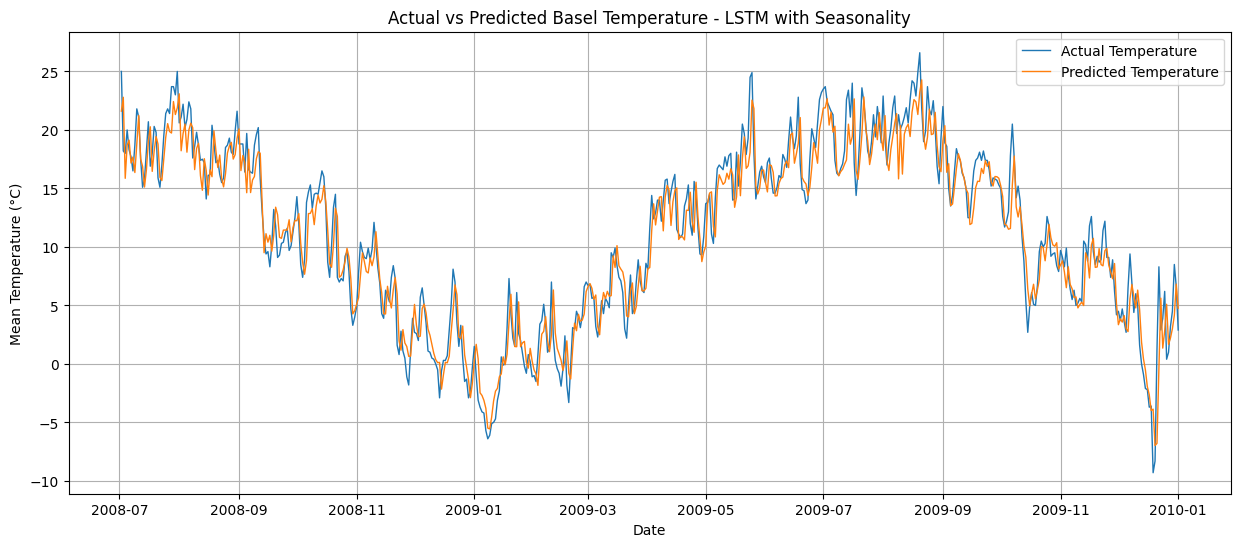

In [ ]:
# Create test dates corresponding to our predictions
test_dates = basel_df["DATE"].iloc[val_end:n].reset_index(drop=True)

# Flatten predictions and actual values
actual_temp = y_test_actual.flatten()
predicted_temp = test_pred_seasonal.flatten()

# Plot actual vs predicted temperature
plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_temp,
    label="Actual Temperature",
    linewidth=1
)

plt.plot(
    test_dates,
    predicted_temp,
    label="Predicted Temperature",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted Basel Temperature - LSTM with Seasonality")

plt.legend()
plt.grid(True)
plt.show()

### **Error/Residual Plot**

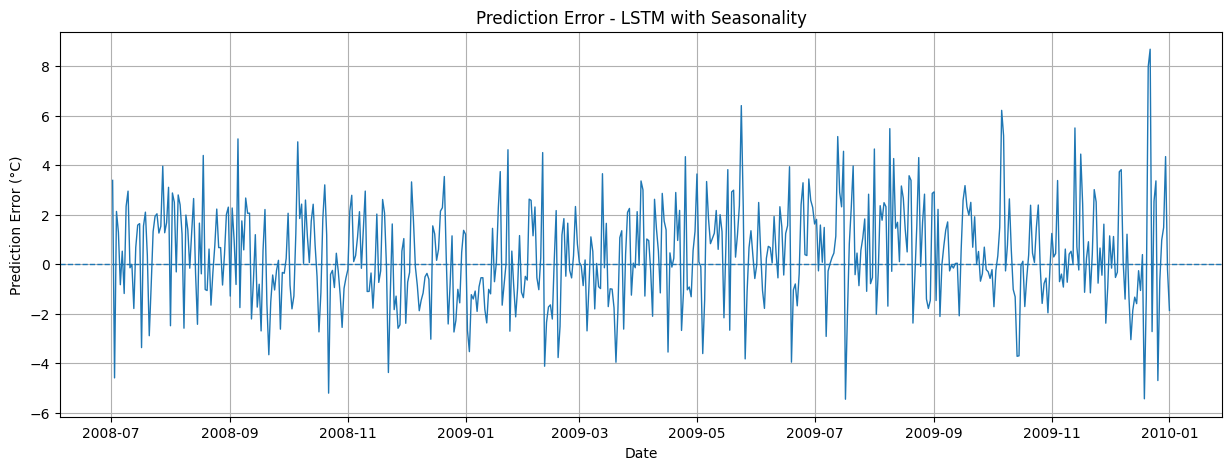

In [ ]:
# Calculate prediction errors
errors = actual_temp - predicted_temp

# Plot prediction errors
plt.figure(figsize=(15, 5))

plt.plot(
    test_dates,
    errors,
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Prediction Error (°C)")
plt.title("Prediction Error - LSTM with Seasonality")
plt.grid(True)
plt.show()